# TP 10 — Projet Final NLP
## Sujet A — Détecteur de désinformation (dataset WELFake)

**Objectif du notebook :** construire un système qui devine si un article est **vrai** ou **faux**.

On va faire ça en 6 grandes étapes, une par une, sans se presser :
1. Installer et importer les outils
2. Charger les données
3. Regarder à quoi ressemblent les données (exploration)
4. Construire un premier modèle simple (baseline)
5. Construire un modèle plus puissant (DistilBERT)
6. Comparer les deux et comprendre les erreurs

> 💡 Chaque cellule de code est commentée en français, ligne par ligne quand c'est utile. Exécutez les cellules **dans l'ordre**, une par une (bouton ▶️ ou `Shift + Entrée`).

> ⚠️ À exécuter sur **Google Colab** avec le GPU activé : menu `Exécution > Modifier le type d'exécution > GPU`.


## Étape 1 — Installer et importer les outils

On installe d'abord les bibliothèques Python dont on a besoin (une seule fois), puis on les importe.


In [1]:
# On installe les bibliothèques nécessaires (à faire une seule fois)
!pip install -q datasets transformers scikit-learn matplotlib pandas evaluate accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [2]:
# On importe les outils dont on va se servir tout au long du notebook

import pandas as pd                  # pour manipuler des tableaux de données
import numpy as np                   # pour faire des calculs numériques
import matplotlib.pyplot as plt      # pour dessiner des graphiques

from datasets import load_dataset    # pour télécharger le dataset WELFake

# Outils pour le modèle simple (baseline)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# On fixe un "seed" pour que les résultats soient les mêmes à chaque exécution
SEED = 42
np.random.seed(SEED)

print("Tout est importé, on peut commencer.")


Tout est importé, on peut commencer.


## Étape 2 — Charger les données

Le dataset s'appelle **WELFake**. Il contient environ 72 000 articles.
Chaque article a :
- un `title` (titre)
- un `text` (contenu)
- un `label` : **0 = fake (faux)**, **1 = real (vrai)**


In [3]:
# On télécharge le dataset depuis Hugging Face
dataset = load_dataset("davanstrien/WELFake")

# On le transforme en tableau pandas, plus simple à manipuler
df = dataset["train"].to_pandas()

# On regarde les premières lignes pour voir à quoi ça ressemble
df.head()


README.md:   0%|          | 0.00/2.37k [00:00<?, ?B/s]

data/train-00000-of-00001-290868f0a36350(…): reconstructing file:   0%|          |  0.00B /  152MB            

data/train-00000-of-00001-290868f0a36350(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/72134 [00:00<?, ? examples/s]

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,None,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
# Combien d'articles avons-nous, et combien de colonnes ?
print("Nombre d'articles :", df.shape[0])
print("Colonnes :", list(df.columns))


Nombre d'articles : 72134
Colonnes : ['title', 'text', 'label']


## Étape 3 — Explorer les données

Avant de construire un modèle, il faut toujours regarder ses données. On va vérifier :
- combien d'articles sont vrais / faux
- s'il y a des données manquantes
- la longueur des textes
- quelques exemples concrets


label
1    37106
0    35028
Name: count, dtype: int64


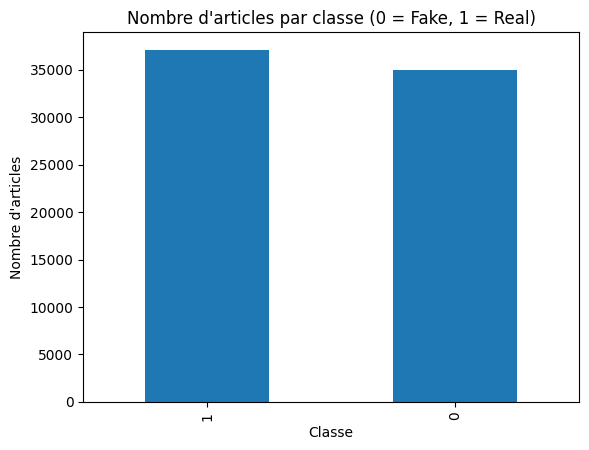

In [5]:
# Combien d'articles vrais et combien de faux ?
print(df["label"].value_counts())

# On dessine un petit graphique pour visualiser
df["label"].value_counts().plot(kind="bar")
plt.title("Nombre d'articles par classe (0 = Fake, 1 = Real)")
plt.xlabel("Classe")
plt.ylabel("Nombre d'articles")
plt.show()


In [6]:
# Est-ce qu'il y a des cases vides dans le tableau ?
print("Valeurs manquantes par colonne :")
print(df.isna().sum())


Valeurs manquantes par colonne :
title    558
text      39
label      0
dtype: int64


In [7]:
# On regarde un exemple d'article FAKE et un exemple d'article REAL

exemple_fake = df[df["label"] == 0].iloc[0]
exemple_real = df[df["label"] == 1].iloc[0]

print("----- Exemple FAKE -----")
print("Titre :", exemple_fake["title"])
print("Texte (début) :", str(exemple_fake["text"])[:300])

print()
print("----- Exemple REAL -----")
print("Titre :", exemple_real["title"])
print("Texte (début) :", str(exemple_real["text"])[:300])


----- Exemple FAKE -----
Titre : Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid
Texte (début) : A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in the context of presidential politics: how Louisiana Gov. Bobby Jindal traveled from Hinduism to Protestant Christianity and, ultimately, became what he calls an “evangelical Catholic.”

----- Exemple REAL -----
Titre : LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO]
Texte (début) : No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about t


## Étape 4 — Préparer les données

On fait 3 choses simples :
1. On enlève les lignes vides ou dupliquées (nettoyage)
2. On combine le titre et le texte en une seule colonne
3. On sépare les données en deux groupes : **entraînement** (80%) et **test** (20%)


In [8]:
# 1. On enlève les lignes où il manque du texte, et les doublons
df_propre = df.dropna(subset=["text", "label"])
df_propre = df_propre.drop_duplicates(subset=["text"])

print("Avant nettoyage :", len(df))
print("Après nettoyage :", len(df_propre))


Avant nettoyage : 72134
Après nettoyage : 62718


In [9]:
# 2. On combine le titre et le texte dans une seule colonne "contenu"
df_propre["contenu"] = df_propre["title"].fillna("") + ". " + df_propre["text"].fillna("")

# 3. On sépare en données d'entraînement (train) et de test
X = df_propre["contenu"]      # les textes
y = df_propre["label"]        # les étiquettes (0 ou 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% pour le test
    random_state=SEED,
    stratify=y            # garde la même proportion de fake/real dans les deux groupes
)

print("Nombre d'articles pour l'entraînement :", len(X_train))
print("Nombre d'articles pour le test :", len(X_test))


Nombre d'articles pour l'entraînement : 50174
Nombre d'articles pour le test : 12544


## Étape 5 — Modèle simple (baseline) : TF-IDF + LinearSVC

C'est notre premier modèle, rapide à construire. Il fonctionne en 2 temps :
1. **TF-IDF** transforme chaque texte en une liste de nombres (le modèle ne comprend pas le texte brut, seulement des nombres)
2. **LinearSVC** apprend à séparer les "fake" des "real" à partir de ces nombres


In [10]:
# On transforme les textes en nombres avec TF-IDF
vectoriseur = TfidfVectorizer(
    max_features=20000,   # on garde les 20 000 mots les plus utiles
    stop_words="english"  # on ignore les mots trop communs (the, a, is...)
)

X_train_nombres = vectoriseur.fit_transform(X_train)
X_test_nombres = vectoriseur.transform(X_test)

print("Transformation terminée.")


Transformation terminée.


In [11]:
# On entraîne le modèle simple
modele_simple = LinearSVC(random_state=SEED)
modele_simple.fit(X_train_nombres, y_train)

print("Entraînement terminé.")


Entraînement terminé.


In [12]:
# On teste le modèle sur les données de test (qu'il n'a jamais vues)
predictions_simple = modele_simple.predict(X_test_nombres)

# On affiche les résultats : précision, rappel, f1-score
print(classification_report(y_test, predictions_simple, target_names=["Fake", "Real"]))


              precision    recall  f1-score   support

        Fake       0.96      0.96      0.96      6924
        Real       0.95      0.95      0.95      5620

    accuracy                           0.96     12544
   macro avg       0.96      0.95      0.96     12544
weighted avg       0.96      0.96      0.96     12544



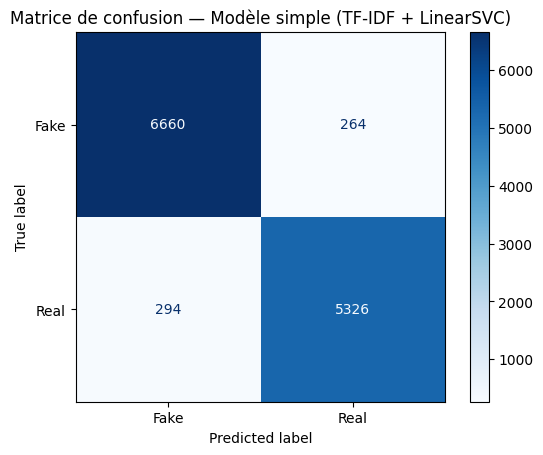

In [13]:
# On dessine la matrice de confusion : où le modèle se trompe-t-il ?
matrice = confusion_matrix(y_test, predictions_simple)
ConfusionMatrixDisplay(matrice, display_labels=["Fake", "Real"]).plot(cmap="Blues")
plt.title("Matrice de confusion — Modèle simple (TF-IDF + LinearSVC)")
plt.show()


## Étape 6 — Modèle avancé : DistilBERT

DistilBERT est un modèle beaucoup plus puissant, qui a déjà "lu" énormément de texte avant même de commencer. On va juste l'**affiner** (fine-tuning) sur nos données.

⚠️ Cette étape prend du temps (10-30 minutes). Pour aller plus vite, on n'utilise qu'une partie des données (15 000 exemples au lieu de 72 000) — c'est un choix raisonnable pour un projet en temps limité, à mentionner dans votre analyse.


### Vérification importante avant de continuer

L'entraînement de DistilBERT est **très lent sans GPU** (parfois plusieurs heures au lieu de quelques minutes). On vérifie d'abord qu'un GPU est bien disponible.

Si la cellule ci-dessous affiche `False`, allez dans le menu **Exécution > Modifier le type d'exécution > GPU (T4)**, puis relancez le notebook depuis le début.

In [14]:
import torch
print("GPU disponible :", torch.cuda.is_available())
print("Nom du GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Aucun (activez le GPU : Exécution > Modifier le type d'exécution > GPU)")

GPU disponible : True
Nom du GPU : Tesla T4


In [15]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import evaluate

NOM_MODELE = "distilbert-base-uncased"

# On prend un échantillon plus petit pour aller plus vite
train_petit = pd.DataFrame({"contenu": X_train, "label": y_train}).sample(n=8000, random_state=SEED)
test_petit = pd.DataFrame({"contenu": X_test, "label": y_test}).sample(n=2000, random_state=SEED)

# On transforme ces tableaux au format attendu par la bibliothèque transformers
train_dataset = Dataset.from_pandas(train_petit.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_petit.reset_index(drop=True))

print("Données prêtes pour DistilBERT.")


Données prêtes pour DistilBERT.


In [16]:
# Le "tokenizer" découpe le texte en petits morceaux (tokens) compris par le modèle
tokenizer = AutoTokenizer.from_pretrained(NOM_MODELE)

def transformer_en_tokens(exemples):
    return tokenizer(exemples["contenu"], truncation=True, max_length=256)

train_dataset = train_dataset.map(transformer_en_tokens, batched=True)
test_dataset = test_dataset.map(transformer_en_tokens, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenisation terminée.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenisation terminée.


In [17]:
# On charge le modèle DistilBERT pré-entraîné, prêt à être affiné pour notre tâche
modele_avance = AutoModelForSequenceClassification.from_pretrained(NOM_MODELE, num_labels=2)

# On définit comment calculer les scores pendant l'entraînement
metrique_accuracy = evaluate.load("accuracy")
metrique_f1 = evaluate.load("f1")

def calculer_scores(resultats):
    logits, labels = resultats
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": metrique_accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "f1": metrique_f1.compute(predictions=predictions, references=labels)["f1"],
    }


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
# On définit les réglages de l'entraînement (paramètres classiques, pas besoin d'y toucher)
parametres_entrainement = TrainingArguments(
    output_dir="./distilbert-welfake",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
)

entraineur = Trainer(
    model=modele_avance,
    args=parametres_entrainement,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=calculer_scores,
)


In [19]:
# On lance l'entraînement (la partie la plus longue)
entraineur.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.041213,0.985500,0.983625
2,0.086624,0.045018,0.987500,0.985884


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.08662393951416016, metrics={'train_runtime': 110.9586, 'train_samples_per_second': 144.198, 'train_steps_per_second': 4.506, 'total_flos': 1059739189248000.0, 'train_loss': 0.08662393951416016, 'epoch': 2.0})

In [20]:
# On évalue le modèle avancé sur les données de test
resultats = entraineur.evaluate()
print(resultats)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.086624,0.045018,2,0.987500,0.985884


{'eval_loss': 0.04501799866557121, 'eval_accuracy': 0.9875, 'eval_f1': 0.9858836815358555}


In [21]:
# On récupère les prédictions détaillées pour les comparer au modèle simple
sortie_predictions = entraineur.predict(test_dataset)
predictions_avance = np.argmax(sortie_predictions.predictions, axis=-1)
vraies_valeurs = test_petit["label"].values

print(classification_report(vraies_valeurs, predictions_avance, target_names=["Fake", "Real"]))


              precision    recall  f1-score   support

        Fake       0.98      1.00      0.99      1107
        Real       0.99      0.98      0.99       893

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



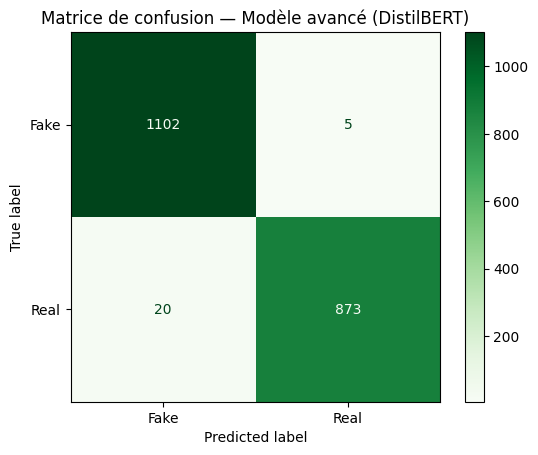

In [22]:
# Matrice de confusion du modèle avancé
matrice_avance = confusion_matrix(vraies_valeurs, predictions_avance)
ConfusionMatrixDisplay(matrice_avance, display_labels=["Fake", "Real"]).plot(cmap="Greens")
plt.title("Matrice de confusion — Modèle avancé (DistilBERT)")
plt.show()


## Étape 7 — Comparer les deux modèles

On met les deux résultats côte à côte pour voir si le modèle avancé apporte vraiment un progrès.


                Modèle  Accuracy  F1-score
0      Simple (TF-IDF)  0.955517  0.950223
1  Avancé (DistilBERT)  0.987500  0.985884


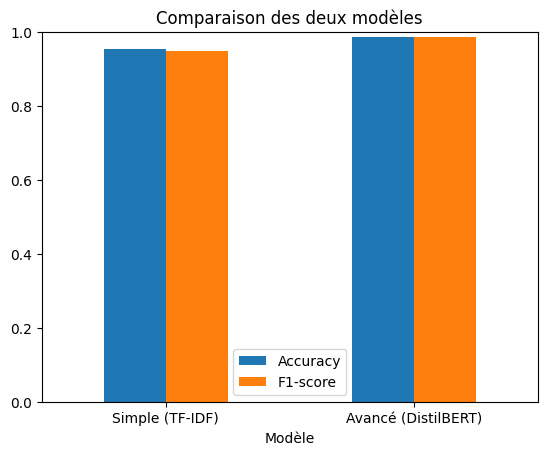

In [23]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_simple = accuracy_score(y_test, predictions_simple)
f1_simple = f1_score(y_test, predictions_simple)

accuracy_avance = accuracy_score(vraies_valeurs, predictions_avance)
f1_avance = f1_score(vraies_valeurs, predictions_avance)

comparaison = pd.DataFrame({
    "Modèle": ["Simple (TF-IDF)", "Avancé (DistilBERT)"],
    "Accuracy": [accuracy_simple, accuracy_avance],
    "F1-score": [f1_simple, f1_avance],
})

print(comparaison)

comparaison.set_index("Modèle").plot(kind="bar")
plt.title("Comparaison des deux modèles")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()


## Étape 8 — Regarder les erreurs

Un bon modèle n'est pas un modèle parfait, c'est un modèle dont on **comprend** les erreurs. On va afficher quelques articles mal classés par le modèle avancé.


In [24]:
# On rassemble les textes de test avec leur vraie étiquette et la prédiction
resultats_test = test_petit.reset_index(drop=True).copy()
resultats_test["prediction"] = predictions_avance
resultats_test["correct"] = resultats_test["label"] == resultats_test["prediction"]

# On isole les erreurs
erreurs = resultats_test[resultats_test["correct"] == False]
print(f"Nombre d'erreurs : {len(erreurs)} sur {len(resultats_test)}")

# On affiche 5 exemples d'erreurs
pd.set_option("display.max_colwidth", 150)
erreurs[["contenu", "label", "prediction"]].head(5)


Nombre d'erreurs : 25 sur 2000


,contenu,label,prediction
3,"Bob Dylan Secretly Longs For Teen Choice Award. Dylan Might Have Gone Electric, But That Doesn't Cut It With Today's Teens. \nNew York, NY - Aft...",1,0
113,"There Should be No Special Deal for Tax-Evading Cameco. Cameco, the Saskatchewan-based uranium mining colossus, is currently in Federal Court faci...",1,0
152,Hillary Clinton agrees to provide private e-mail server to FBI. Hillary Rodham Clinton’s attorney has agreed to provide the FBI with the private s...,0,1
227,Putin and Obama: the Trust Evaporates. How did the “growing trust” that Russian President Vladimir Putin once said marked his “working and persona...,1,0
309,"Stockholm’s “Feminist” Snow Removal Program Causes The Entire City To Shut Down. Convinced that previous snow plowing policies were “sexist,” the ...",1,0


**À faire vous-même :** lisez ces 5 exemples et essayez de comprendre pourquoi le modèle s'est trompé (texte trop court ? ironie ? sujet ambigu ?). Notez vos observations, c'est ça "l'analyse honnête des limites" demandée dans le barème.

## Étape 9 — Quels mots influencent le plus la décision ?

On regarde, dans le modèle simple, quels mots poussent le plus vers "Fake" ou vers "Real". C'est utile pour expliquer les prédictions dans l'application.


In [25]:
# On récupère la liste des mots utilisés par le modèle simple
mots = np.array(vectoriseur.get_feature_names_out())

# Le modèle simple donne un "poids" à chaque mot : positif = plutôt Real, négatif = plutôt Fake
poids = modele_simple.coef_[0]

# On trie et on affiche les 15 mots les plus associés à chaque classe
top_real = mots[np.argsort(poids)[-15:]]
top_fake = mots[np.argsort(poids)[:15]]

print("Mots les plus associés à REAL :", list(top_real))
print()
print("Mots les plus associés à FAKE :", list(top_fake))


Mots les plus associés à REAL : ['snip', 'wire', 'wfb', 'november', 'nyp', 'hillary', 'read', 'october', 'video', 'flickr', 'com', 'breaking', 'image', 'getty', 'featured']

Mots les plus associés à FAKE : ['reuters', 'breitbart', 'follow', 'said', 'york', 'twitter', '2017', 'thursday', 'jeromeehudson', 'friday', 'factbox', 'monday', 'tuesday', 'jeff_poor', 'jerome']


## Étape 10 — Sauvegarder les modèles

On sauvegarde les deux modèles pour pouvoir les réutiliser dans l'application Streamlit, sans avoir à tout ré-entraîner.


In [26]:
import joblib

# On sauvegarde le modèle simple et son vectoriseur
joblib.dump(vectoriseur, "tfidf_vectoriseur.joblib")
joblib.dump(modele_simple, "modele_simple.joblib")

# On sauvegarde le modèle avancé
entraineur.save_model("./modele_avance_final")
tokenizer.save_pretrained("./modele_avance_final")

print("Tout est sauvegardé, prêt pour l'application !")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Tout est sauvegardé, prêt pour l'application !


---
## Et après ?
1. Construire l'application Streamlit (`app.py`) qui charge ces modèles sauvegardés.
2. La déployer sur Hugging Face Spaces.
3. Écrire le README du projet.
4. Préparer la soutenance (10 min).


In [27]:
!ls -la

total 912
drwxr-xr-x 1 root root   4096 Jul 29 17:15 .
drwxr-xr-x 1 root root   4096 Jul 29 17:00 ..
drwxr-xr-x 4 root root   4096 Jun  4 13:39 .config
drwxr-xr-x 4 root root   4096 Jul 29 17:15 distilbert-welfake
drwxr-xr-x 2 root root   4096 Jul 29 17:15 modele_avance_final
-rw-r--r-- 1 root root 160731 Jul 29 17:15 modele_simple.joblib
drwxr-xr-x 1 root root   4096 Jun  4 13:39 sample_data
-rw-r--r-- 1 root root 745212 Jul 29 17:15 tfidf_vectoriseur.joblib


In [28]:
!zip -r modele_avance_final.zip modele_avance_final

  adding: modele_avance_final/ (stored 0%)
  adding: modele_avance_final/model.safetensors (deflated 8%)
  adding: modele_avance_final/training_args.bin (deflated 54%)
  adding: modele_avance_final/tokenizer_config.json (deflated 43%)
  adding: modele_avance_final/config.json (deflated 49%)
  adding: modele_avance_final/tokenizer.json (deflated 71%)


In [29]:
print("test")

test
